## This notebook compares loss plots for any two experiments.

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# meta
_scratch = "/pscratch/sd/n/nagarwal"
_prototype = "ocn-only"
_expt = "R3"

In [9]:
# experiments
loss1 = xr.open_dataset(os.path.join(_scratch, _prototype, _expt, "loss.nc"))
loss2 = xr.open_dataset(os.path.join(_scratch, _prototype, _expt, "training_with_wrong_stats/loss.nc"))

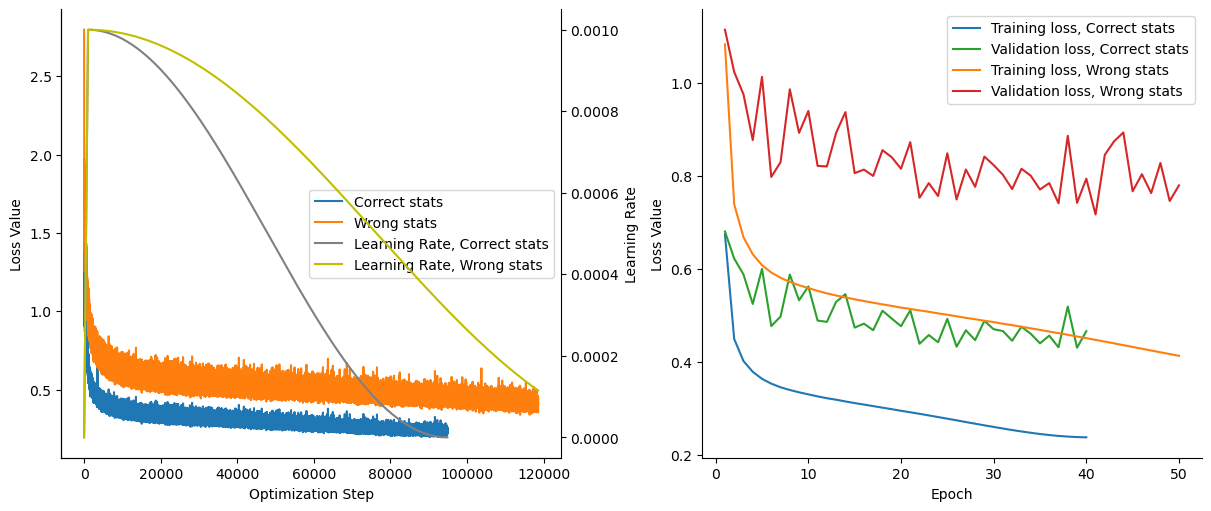

In [10]:
# Plot
fig, axs = plt.subplots(1,2, figsize=(12,5), constrained_layout=True)

axLR = axs[0].twinx()

# loss per optim step
l10 = loss1.loss.plot(ax=axs[0], color="C0", label="Correct stats")
l11 = loss2.loss.plot(ax=axs[0], color="C1", label="Wrong stats")

# learning rate
l20 = loss1.learning_rate.plot(ax=axLR, color="gray", label="Learning Rate, Correct stats")
l21 = loss2.learning_rate.plot(ax=axLR, color="y", label="Learning Rate, Wrong stats")

# loss per epoch
loss1.loss_avg.plot(ax=axs[1], color="C0", label="Training loss, Correct stats")
loss1.loss_valid.plot(ax=axs[1], color="C2", label="Validation loss, Correct stats")

loss2.loss_avg.plot(ax=axs[1], color="C1", label="Training loss, Wrong stats")
loss2.loss_valid.plot(ax=axs[1], color="C3", label="Validation loss, Wrong stats")

for ax in axs:
    for key in ["right", "top"]:
        ax.spines[key].set_visible(False)
axLR.spines["top"].set_visible(False)

# labels etc
axs[0].set(
    xlabel="Optimization Step",
    ylabel="Loss Value",
)
axLR.set(ylabel="Learning Rate")
axs[1].set(
    xlabel="Epoch",
    ylabel="Loss Value",
)
lines = [l10[0], l11[0], l20[0], l21[0]]
axs[0].legend(
    lines,
    list(l.get_label() for l in lines),
    loc="center right",
)
axs[1].legend()
plt.savefig(f"figures/compare_loss_{_prototype}_{_expt}_with_correct_and_wrong_stats.png", dpi=300)
plt.show()